<style>
.jp-MarkdownOutput {
    max-width: 800px;
    margin: 0 auto;
    padding: 0 40px;
}
.jp-MarkdownOutput p {
    text-align: justify;
    line-height: 1.8;
    font-family: Georgia, serif;
    font-size: 14px;
}
.jp-MarkdownOutput h1 {
    font-family: Arial, sans-serif;
    font-size: 22px;
    font-weight: bold;
}
.jp-MarkdownOutput h2 {
    font-family: Arial, sans-serif;
    font-size: 18px;
    font-weight: bold;
    margin-top: 20px;
}
.jp-MarkdownOutput h3 {
    font-family: Arial, sans-serif;
    font-size: 15px;
    font-weight: bold;
    margin-top: 15px;
}
.jp-MarkdownOutput {
    max-width: 800px;
    margin: 0 auto;
    padding: 0 40px;
}
.jp-MarkdownOutput p {
    text-align: justify;
    line-height: 1.8;
    font-family: Georgia, serif;
    font-size: 14px;
}
.jp-MarkdownOutput h1 {
    font-family: Arial, sans-serif;
    font-size: 22px;
    font-weight: bold;
}
.jp-MarkdownOutput h2 {
    font-family: Arial, sans-serif;
    font-size: 18px;
    font-weight: bold;
    margin-top: 20px;
}
.jp-MarkdownOutput h3 {
    font-family: Arial, sans-serif;
    font-size: 15px;
    font-weight: bold;
    margin-top: 15px;
}
/* Hidden code cell number */
.jp-InputPrompt {
    display: none;
}
.jp-OutputPrompt {
    display: none;
}
/* Body text alignment and line spacing */
.jp-MarkdownOutput p {
    text-align: justify;
    line-height: 1.8;
    font-family: 'Georgia', serif;
    font-size: 11pt;
}

/* Title Style */
.jp-MarkdownOutput p {
    text-align: justify;
    line-height: 1.8;
    font-family: Georgia, serif;
    font-size: 14px;
}
.jp-MarkdownOutput h1 {
    font-family: Arial, sans-serif;
    font-size: 22px;
    font-weight: bold;
}
.jp-MarkdownOutput h2 {
    font-family: Arial, sans-serif;
    font-size: 18px;
    font-weight: bold;
    margin-top: 20px;
}
.jp-MarkdownOutput h3 {
    font-family: Arial, sans-serif;
    font-size: 15px;
    font-weight: bold;
    margin-top: 15px;
}

/* Code block style */
.jp-MarkdownOutput {
    max-width: 800px;
    margin: 0 auto;
    padding: 0 40px;
}
.jp-MarkdownOutput p {
    text-align: justify;
    line-height: 1.8;
    font-family: Georgia, serif;
    font-size: 14px;
}
.jp-MarkdownOutput h1 {
    font-family: Arial, sans-serif;
    font-size: 22px;
    font-weight: bold;
}
.jp-MarkdownOutput h2 {
    font-family: Arial, sans-serif;
    font-size: 18px;
    font-weight: bold;
    margin-top: 20px;
}
.jp-MarkdownOutput h3 {
    font-family: Arial, sans-serif;
    font-size: 15px;
    font-weight: bold;
    margin-top: 15px;
}
.jp-InputPrompt {
    display: none;
}
.jp-OutputPrompt {
    display: none;
}
/* 只处理溢出，不改变换行行为 */
.jp-CodeCell .jp-Editor pre {
    overflow-x: auto;
    font-size: 9px;
}

</style>

---

**About this document**

*This is the assignment for the UCL CASA module Data Science for Spatial Systems (CASA0006).
This is a self-contained Jupyter notebook with structured introduction, methodology, analysis and bibliography.*

**Data is available [here](https://github.com/siyi-w/DSSS/tree/main/as/data)**

---

# Two-Wheeler Collision Severity in London: A Spatio-Temporal Analysis

*Using Machine Learning to Identify Risk Factors and Safety Intervention Priorities*

*This study examines how temporal patterns, road infrastructure characteristics, and fine-grained land use environments jointly influence the severity of two-wheeler collisions in London, using DfT 2025 provisional road safety data enriched with OpenStreetMap land use information.*

---

| [1.0 Introduction](#) | [2.0 Research Questions](#) | [3.0 Data](#) | [4.0 Methodology](#) | [5.0 Results & Discussion](#) | [6.0 Conclusion](#) | [References](#) |

---


## 1.0 Introduction

Road traffic collisions remain a significant public health challenge in the UK. 
In 2024, 128,272 casualty accidents were reported, of which 29,467 resulted in 
death or serious injury (DfT, 2025). Vulnerable road users bear a disproportionate 
share of this risk: two-wheeled riders accounted for 26% of road traffic fatalities 
in 2024, with motorcyclist fatalities increasing by 8% (DfT, 2025). The rapid growth 
of gig economy food delivery platforms has significantly increased two-wheeler 
presence on urban streets, with gig riders nearly twice as likely to report collision 
injuries compared to employed riders due to per-delivery pay structures incentivising 
speed (Christie & Ward, 2023). Despite growing investment in cycling infrastructure, 
cyclists and motorcyclists remain among the highest-risk road users, with the 
smallest reduction in fatality rates among all road user groups in recent years 
(European Commission, 2025).

Research consistently identifies temporal and spatial factors as key predictors of 
two-wheeler collision severity. Night-time crashes are associated with greater injury 
severity (Jingjing et al., 2026), while road type, junction characteristics, and 
land use context all influence collision outcomes (Xiao et al., 2025; Antonella et 
al., 2023). However, existing studies rarely integrate fine-grained land use data 
with temporal and infrastructure factors in a unified predictive framework. A study of motorcycle crashes in Thailand demonstrated that random forest 
outperformed seven other algorithms in predicting fatal outcomes (Mohamad 
et al., 2025). Machine 
learning methods, particularly random forest classifiers combined with SHAP 
interpretability tools, have demonstrated strong performance in collision severity 
modelling (Antonella et al., 2023; Antonella et al., 2025).

This study uses DfT 2025 provisional road safety statistics, spatially joined with 
OpenStreetMap land use data, to examine how temporal patterns, road infrastructure, 
and land use environments jointly influence two-wheeler collision severity in London, 
and to identify which factors offer the greatest potential for safety interventions.



## 2.0 Research Questions


**RQ1:** What factors are associated with the severity of two-wheeler collisions in London?

**RQ2:** Which factors contribute most to predicting serious or fatal collision outcomes, and what do they imply for road safety interventions?


In [ ]:
# Import Libraries

!pip install imbalanced-learn shap osmium --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import geopandas as gpd
import zipfile, io, requests
import osmium
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip




## 3.0 Data


This study used three datasets from the UK Department for Transport 2025 road safety statistics: a collision table, a vehicle table, and an injury table. 


In [ ]:
# 3.1 Load and Merge Data

collision_url = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/data/dft-road-casualty-statistics-collision-provisional-2025.csv"
vehicle_url   = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/data/dft-road-casualty-statistics-vehicle-provisional-2025.csv"
casualty_url  = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/data/dft-road-casualty-statistics-casualty-provisional-2025.csv"

df_collision = pd.read_csv(collision_url)
df_vehicle   = pd.read_csv(vehicle_url)
df_casualty  = pd.read_csv(casualty_url)

print(f"Collision records : {len(df_collision):,}")
print(f"Vehicle records   : {len(df_vehicle):,}")
print(f"Casualty records  : {len(df_casualty):,}")

Collision records : 48,472
Vehicle records   : 87,805
Casualty records  : 60,991




This study focuses on two-wheeled vehicle collisions in London. 


In [ ]:
# 3.2 Data Cleaning, Filtering and Feature Engineering

# 3.2.1 Filter London (Metropolitan Police=1, City of London=2) 
# First, accidents were filtered to the Metropolitan Police and the City of London Metropolitan Police (police_force = 1 and 2).
# Resulting in 10,062 collisions in London. 

df_london = df_collision[df_collision['police_force'].isin([1, 2])].copy()
print(f"London collisions: {len(df_london):,}")

London collisions: 10,062


In [ ]:
#  3.2.2 Filter two-wheelers and merge vehicle_type 

#Then, the vehicle table was used to identify collisions involving two-wheeled vehicles, 
# defined as bicycles, motorcycles with an engine displacement of no more than 500cc, motorcycles with an engine displacement greater than 500cc, and electric motorcycles (vehicle_type = 1, 2, 3, 4, 5, 23), ultimately yielding 4,966 collision records.

two_wheeler_types = [1, 2, 3, 4, 5, 23]
df_tw_vehicle = df_vehicle[df_vehicle['vehicle_type'].isin(two_wheeler_types)]
tw_ids = df_tw_vehicle['collision_index'].unique()
df_tw = df_london[df_london['collision_index'].isin(tw_ids)].copy()
print(f"London two-wheeler collisions: {len(df_tw):,}")

df_tw = df_tw.merge(
    df_tw_vehicle[['collision_index', 'vehicle_type']].drop_duplicates('collision_index'),
    on='collision_index',
    how='left'
)

print("Vehicle type distribution:")
print(df_tw['vehicle_type'].value_counts())

London two-wheeler collisions: 4,966
Vehicle type distribution:
vehicle_type
1     2693
3     1601
5      359
4      184
2       72
23      57
Name: count, dtype: int64




The outcome variable is a binary collision severity , with serious or fatal accidents coded as 1 and minor injuries coded as 0. The final class distribution is approximately 80% minor injuries and 20% serious or fatal accidents, reflecting the class imbalance problem addressed by applying SMOTE oversampling only to the training set.


In [ ]:
#  3.2.3 Binary severity target 

df_tw['severity_binary'] = (df_tw['collision_severity'] <= 2).astype(int)
print(f"\nSeverity distribution:")
print(df_tw['severity_binary'].value_counts(normalize=True).round(3))

#  3.2.4 Time features 

df_tw['date'] = pd.to_datetime(df_tw['date'], dayfirst=True)
df_tw['hour'] = df_tw['time'].str[:2].astype(float)
df_tw['is_weekend'] = (df_tw['day_of_week'] >= 5).astype(int)



Severity distribution:
severity_binary
0    0.796
1    0.204
Name: proportion, dtype: float64




To capture land use context, London's OpenStreetMap land use polygons are spatially connected to the collision points. 


In [ ]:
#  3.3 OSM Landuse Spatial Join (50m buffer) 

#Since collisions on roads often occur outside of land use polygons, the matching rate for direct intra-point polygon matching is only 20.8%. 
# Therefore, a 50-meter buffer is applied to unmatched points, improving the overall matching rate to 97.5%. 
# Land use categories are simplified to five: residential, commercial, green space, industrial, and others.

zip_url = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/data/landuse/osm.zip"
r = requests.get(zip_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/landuse/")

landuse = gpd.read_file("/tmp/landuse/gis_osm_landuse_a_free_1.shp",
                        columns=['fclass', 'geometry'])

landuse_map = {
    'retail': 'commercial', 'commercial': 'commercial',
    'industrial': 'industrial', 'residential': 'residential',
    'park': 'green', 'grass': 'green', 'forest': 'green',
    'meadow': 'green', 'scrub': 'green',
    'recreation_ground': 'green', 'farmland': 'green',
    'farmyard': 'green', 'heath': 'green',
    'allotments': 'green', 'cemetery': 'green',
}
landuse['landuse_class'] = landuse['fclass'].map(landuse_map).fillna('other')

landuse = landuse[landuse['landuse_class'] != 'other'].copy()
print(f"Landuse polygons (filtered): {len(landuse):,}")

gdf_tw = gpd.GeoDataFrame(
    df_tw.copy(),
    geometry=gpd.points_from_xy(df_tw['longitude'], df_tw['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=27700)
landuse = landuse.to_crs(epsg=27700)
joined = gpd.sjoin(gdf_tw, landuse[['geometry', 'landuse_class']],
                   how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]
unmatched = joined[joined['landuse_class'].isna()].index
print(f"Direct match: {joined['landuse_class'].notna().sum():,}, Unmatched: {len(unmatched):,}")

if len(unmatched) > 0:
    gdf_un = gdf_tw.loc[unmatched].copy()
    gdf_un['geometry'] = gdf_un.geometry.buffer(50)
    joined_buf = gpd.sjoin(gdf_un, landuse[['geometry', 'landuse_class']],
                           how='left', predicate='intersects')
    joined_buf = joined_buf[~joined_buf.index.duplicated(keep='first')]
    joined.loc[unmatched, 'landuse_class'] = joined_buf['landuse_class']

joined['landuse_class'] = joined['landuse_class'].fillna('other')
df_tw['landuse_class'] = joined['landuse_class'].values
print(f"\nLanduse distribution:")
print(df_tw['landuse_class'].value_counts())

Landuse polygons (filtered): 79,672
Direct match: 1,035, Unmatched: 3,931

Landuse distribution:
landuse_class
residential    2981
commercial     1046
green           697
industrial      124
other           118
Name: count, dtype: int64




To capture the intensity of gig economy delivery and use it as an indicator of two-wheeler exposure, we calculate the food density at each collision point. The Greater London OSM file is available at: https://download.geofabrik.de/europe/great-britain/england/greater-london.html 



In [ ]:
#  3.4 Food Establishment Density (500m buffer) 

# Locations of restaurants, cafes, fast food outlets, and food courts (amenity = restaurant, cafe, fast_food, food_court) were extracted from the Greater London OpenStreetMap dataset (Geofabrik, 2024) and analyzed using the osmium library, resulting in 14,739 food establishments.
# Calculated the number of food establishments within a 500-meter buffer zone at each collision point and used this as food_density, serving as a spatial indicator of local delivery demand intensity.

food_density_url = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/data/food_density_precomputed.csv"
pbf_path = '/Users/wusiyi/Documents/CASA/dsss_data/greater-london-260424.osm.pbf'

if 'food_density' in df_tw.columns:
    df_tw = df_tw.drop(columns=['food_density'])

food_loaded = False

try:
    food_density_pre = pd.read_csv(food_density_url)
    df_tw = df_tw.merge(food_density_pre, on='collision_index', how='left')
    df_tw['food_density'] = df_tw['food_density'].fillna(0)
    print(f"Food density loaded from GitHub, mean: {df_tw['food_density'].mean():.1f}")
    food_loaded = True

except Exception as e:
    print(f"GitHub CSV not found ({e}), will compute from local pbf...")

if not food_loaded:
    class FoodHandler(osmium.SimpleHandler):
        def __init__(self):
            super().__init__()
            self.foods = []

        def node(self, n):
            amenity = n.tags.get('amenity', '')
            if amenity in ['restaurant', 'cafe', 'fast_food', 'food_court']:
                self.foods.append({
                    'lat': n.location.lat,
                    'lon': n.location.lon
                })

    handler = FoodHandler()
    handler.apply_file(pbf_path)
    df_food = pd.DataFrame(handler.foods)

    gdf_food = gpd.GeoDataFrame(
        df_food,
        geometry=gpd.points_from_xy(df_food['lon'], df_food['lat']),
        crs='EPSG:4326'
    ).to_crs(epsg=27700)

    gdf_accidents = gpd.GeoDataFrame(
        df_tw.copy(),
        geometry=gpd.points_from_xy(df_tw['longitude'], df_tw['latitude']),
        crs='EPSG:4326'
    ).to_crs(epsg=27700)

    gdf_accidents_buf = gdf_accidents.copy()
    gdf_accidents_buf['geometry'] = gdf_accidents_buf.geometry.buffer(500)

    joined_food = gpd.sjoin(
        gdf_accidents_buf[['collision_index', 'geometry']],
        gdf_food[['geometry']],
        how='left',
        predicate='contains'
    )

    food_density = joined_food.groupby('collision_index').size().reset_index()
    food_density.columns = ['collision_index', 'food_density']

    df_tw = df_tw.merge(food_density, on='collision_index', how='left')
    df_tw['food_density'] = df_tw['food_density'].fillna(0)
    df_tw[['collision_index', 'food_density']].to_csv(
        'food_density_precomputed.csv', index=False)
    print(f"Food density computed and saved, mean: {df_tw['food_density'].mean():.1f}")

Food density loaded from GitHub, mean: 27.4


In [80]:
#  3.5 One-Hot Encoding for Landuse 

landuse_dummies = pd.get_dummies(df_tw['landuse_class'], prefix='lu').astype(int)
df_tw = pd.concat([df_tw.reset_index(drop=True),
                   landuse_dummies.reset_index(drop=True)], axis=1)
landuse_cols = [c for c in df_tw.columns if c.startswith('lu_')]
landuse_cols = [c for c in landuse_cols if c != 'lu_commercial']  # commercial as baseline
print(f"Landuse dummy columns: {landuse_cols}")

Landuse dummy columns: ['lu_green', 'lu_industrial', 'lu_other', 'lu_residential']




Vehicle type was retained as a predictor to distinguish between bicycles, motorcycles, and electric two-wheelers, as their severity differed significantly. Multicollinearity was assessed using the variance inflation factor.


In [81]:
#  3.6 VIF Check and Feature Selection 

features_vif = ['hour', 'is_weekend',
                'road_type', 'first_road_class', 'speed_limit', 'junction_detail',
                'light_conditions', 'weather_conditions',
                'road_surface_conditions', 'urban_or_rural_area',
                'number_of_vehicles', 'number_of_casualties',
                'vehicle_type', 'food_density'] + landuse_cols

df_vif = df_tw[features_vif].dropna().copy()
vif_data = pd.DataFrame({
    'Feature': features_vif,
    'VIF': [variance_inflation_factor(df_vif.values.astype(float), i)
            for i in range(len(features_vif))]
})
print("\nVIF Results:")
print(vif_data.sort_values('VIF', ascending=False).to_string())

#Since urban_or_rural_area had a VIF of 35.3, it was excluded from the final model, while all retained features had VIF values below 12.



VIF Results:
                    Feature        VIF
9       urban_or_rural_area  35.307557
10       number_of_vehicles  20.875775
11     number_of_casualties  20.180986
4               speed_limit  15.103528
3          first_road_class  11.423762
0                      hour   8.929185
2                 road_type   8.076101
17           lu_residential   4.342748
8   road_surface_conditions   3.075559
7        weather_conditions   2.910444
6          light_conditions   2.722518
1                is_weekend   1.883935
12             vehicle_type   1.857247
14                 lu_green   1.843489
13             food_density   1.663174
5           junction_detail   1.643165
16                 lu_other   1.186985
15            lu_industrial   1.161277


In [82]:
#  3.7 Feature Selection 
#   Remove urban_or_rural_area due to extreme multicollinearity (VIF=35.3)

features = ['hour', 'is_weekend',
            'road_type', 'first_road_class', 'speed_limit', 'junction_detail',
            'light_conditions', 'weather_conditions',
            'road_surface_conditions',
            'number_of_vehicles', 'number_of_casualties',
            'vehicle_type', 'food_density'] + landuse_cols

df_model = df_tw[features + ['severity_binary']].dropna()
print(f"\nFinal modelling dataset: {len(df_model):,} rows")
print(f"Serious/Fatal rate: {df_model['severity_binary'].mean():.1%}")
print(f"Number of features: {len(features)}")


Final modelling dataset: 4,966 rows
Serious/Fatal rate: 20.4%
Number of features: 17




##  4.0 Methodolgy


This study employs four analytical methods to address the research questions sequentially.

First, Exploratory Data Analysis including a correlation heatmap was conducted 
to identify patterns in collision severity across temporal, road infrastructure, and 
land use dimensions, guiding feature selection for subsequent modelling. OSM land use 
polygons were initially joined directly to collision points, achieving only a 20.8% 
match rate as most collisions occur on roads outside land use boundaries. A 50-metre 
buffer was therefore applied to unmatched points, improving the match rate to 97.5%. 
As two-wheeler-specific flow data was unavailable — TfL cycle counts cover only pedal 
cycles — food establishment density was computed as the count of 
restaurants, cafes, and fast food outlets within a 500-metre buffer of each collision 
point, serving as a spatial proxy for gig economy delivery intensity (Christie & Ward, 
2023). Multicollinearity was assessed using VIF; urban_or_rural_area was excluded due 
to a VIF of 35.3, with all retained features below 12.



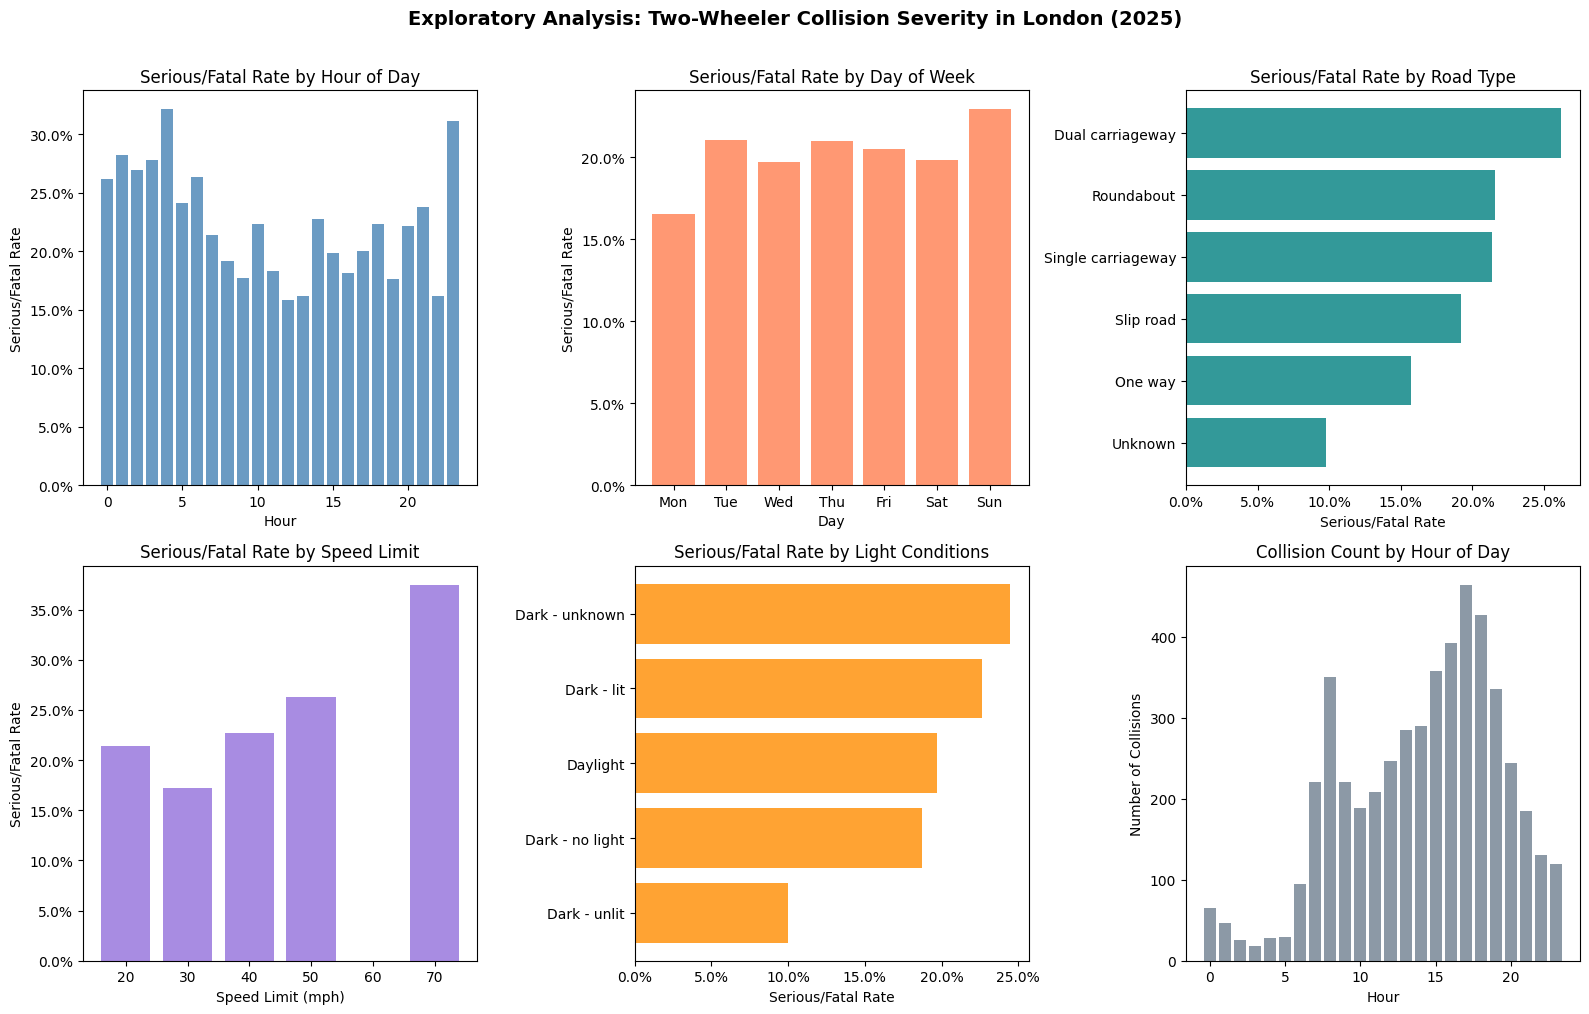

In [83]:
# 4.1 EDA 

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Analysis: Two-Wheeler Collision Severity in London (2025)',
             fontsize=14, fontweight='bold', y=1.01)

# 4.1.1 Severity rate by hour 
hourly = df_model.groupby('hour')['severity_binary'].mean().reset_index()
axes[0,0].bar(hourly['hour'], hourly['severity_binary'], color='steelblue', alpha=0.8)
axes[0,0].set_title('Serious/Fatal Rate by Hour of Day')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Serious/Fatal Rate')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4.1.2 Severity rate by day of week
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df_tw.groupby('day_of_week')['severity_binary'].mean()
axes[0,1].bar(day_labels, daily.values, color='coral', alpha=0.8)
axes[0,1].set_title('Serious/Fatal Rate by Day of Week')
axes[0,1].set_xlabel('Day'); axes[0,1].set_ylabel('Serious/Fatal Rate')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4.1.3 Severity rate by road type 
road_labels = {1:'Roundabout', 2:'One way', 3:'Dual carriageway',
               6:'Single carriageway', 7:'Slip road', 9:'Unknown'}
df_model['road_type_label'] = df_model['road_type'].map(road_labels).fillna('Other')
road = df_model.groupby('road_type_label')['severity_binary'].mean().sort_values(ascending=True)
axes[0,2].barh(road.index, road.values, color='teal', alpha=0.8)
axes[0,2].set_title('Serious/Fatal Rate by Road Type')
axes[0,2].set_xlabel('Serious/Fatal Rate')
axes[0,2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4.1.4 Severity rate by speed limit
speed = df_model.groupby('speed_limit')['severity_binary'].mean().reset_index()
axes[1,0].bar(speed['speed_limit'].astype(str), speed['severity_binary'],
              color='mediumpurple', alpha=0.8)
axes[1,0].set_title('Serious/Fatal Rate by Speed Limit')
axes[1,0].set_xlabel('Speed Limit (mph)'); axes[1,0].set_ylabel('Serious/Fatal Rate')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4.1.5 Severity rate by light conditions 
light_labels = {1:'Daylight', 4:'Dark - lit', 5:'Dark - unlit', 6:'Dark - no light', 7:'Dark - unknown'}
df_model['light_label'] = df_model['light_conditions'].map(light_labels).fillna('Other')
light = df_model.groupby('light_label')['severity_binary'].mean().sort_values(ascending=True)
axes[1,1].barh(light.index, light.values, color='darkorange', alpha=0.8)
axes[1,1].set_title('Serious/Fatal Rate by Light Conditions')
axes[1,1].set_xlabel('Serious/Fatal Rate')
axes[1,1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4.1.6 Collision count by hour (volume context) 
hour_count = df_model.groupby('hour').size()
axes[1,2].bar(hour_count.index, hour_count.values, color='slategray', alpha=0.8)
axes[1,2].set_title('Collision Count by Hour of Day')
axes[1,2].set_xlabel('Hour'); axes[1,2].set_ylabel('Number of Collisions')

plt.tight_layout()
plt.savefig('eda_severity.png', dpi=150, bbox_inches='tight')
plt.show()

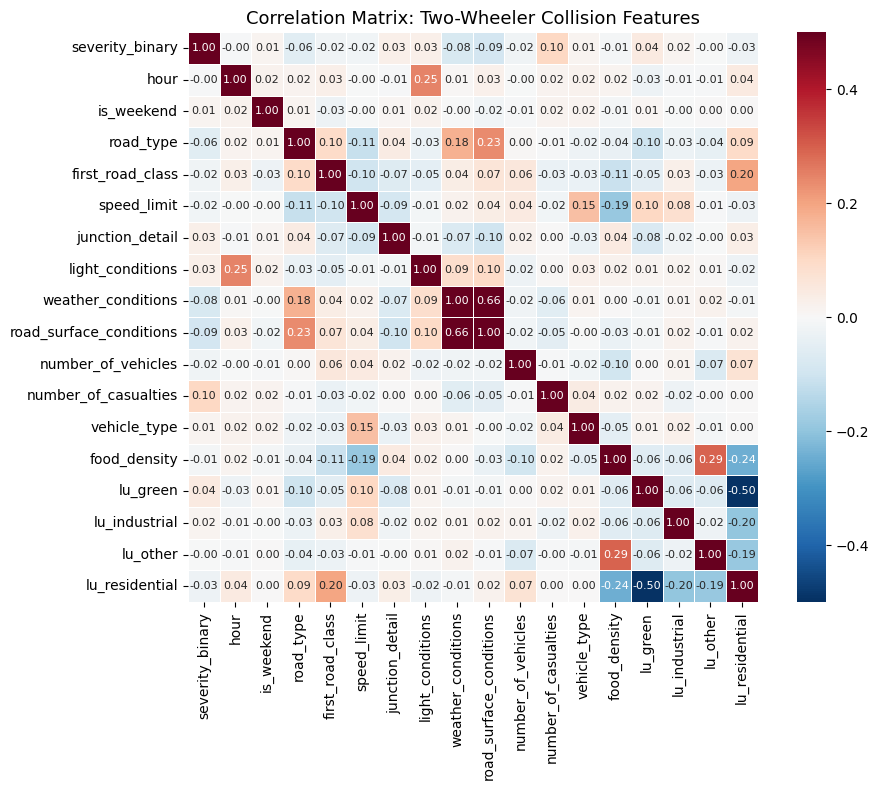


Top correlations with severity_binary:
number_of_casualties       0.104
road_surface_conditions    0.091
weather_conditions         0.080
road_type                  0.055
lu_green                   0.045
junction_detail            0.030
light_conditions           0.029
lu_residential             0.026
Name: severity_binary, dtype: float64


In [84]:
#  4.1.7 Correlation Heatmap 

fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['severity_binary', 'hour', 'is_weekend',
             'road_type', 'first_road_class', 'speed_limit', 'junction_detail',
             'light_conditions', 'weather_conditions',
             'road_surface_conditions',
             'number_of_vehicles', 'number_of_casualties',
             'vehicle_type', 'food_density'] + landuse_cols

corr_matrix = df_model[corr_cols].corr()

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Correlation Matrix: Two-Wheeler Collision Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with severity_binary:")
print(corr_matrix['severity_binary'].drop('severity_binary').abs()
      .sort_values(ascending=False).head(8).round(3))



Secondly, logistic regression was applied to quantify the direction and strength of each factor's association with severe or fatal consequences. Before model fitting, the SMOTE algorithm was applied to the training set to address class imbalance, generating a balanced training distribution with 3163 samples per class.


In [85]:
#   4.2 Logistic Regression

X = df_model[features].copy()

# Ensure all columns are numeric
# The One-Hot column is a boolean value, which should be converted to an int
for col in landuse_cols:
    X[col] = X[col].astype(int)

y = df_model['severity_binary']

print("Feature dtypes:")
print(X.dtypes)
print(f"\nX shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#   4.2.1 SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE - Training set class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}")

Feature dtypes:
hour                       float64
is_weekend                   int64
road_type                    int64
first_road_class             int64
speed_limit                  int64
junction_detail              int64
light_conditions             int64
weather_conditions           int64
road_surface_conditions      int64
number_of_vehicles           int64
number_of_casualties         int64
vehicle_type                 int64
food_density                 int64
lu_green                     int64
lu_industrial                int64
lu_other                     int64
lu_residential               int64
dtype: object

X shape: (4966, 17)
After SMOTE - Training set class distribution: {0: 3163, 1: 3163}



--- Logistic Regression ---
               precision    recall  f1-score   support

       Slight       0.81      0.70      0.75       791
Serious/Fatal       0.23      0.34      0.28       203

     accuracy                           0.63       994
    macro avg       0.52      0.52      0.51       994
 weighted avg       0.69      0.63      0.65       994

ROC-AUC: 0.527


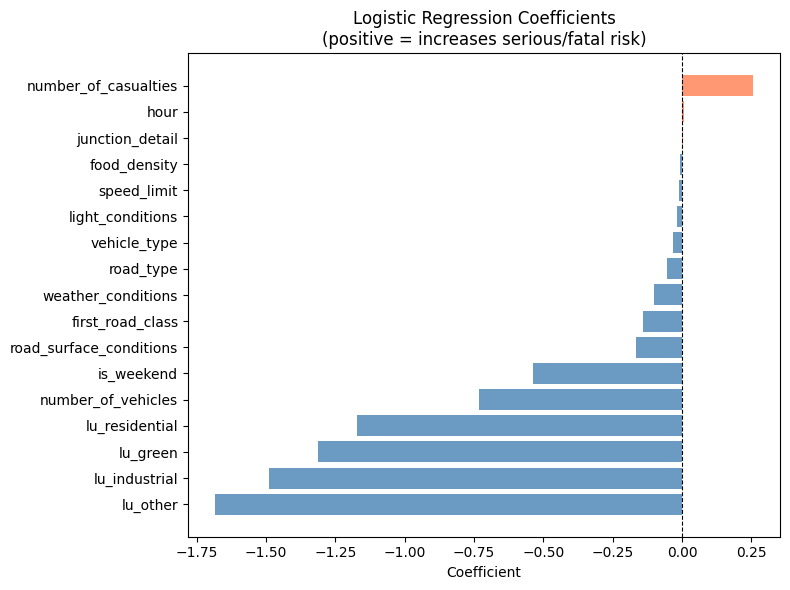

In [86]:
#   4.2.2 Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

#   4.2.3 Evaluate
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Slight','Serious/Fatal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

#   4.2.4 Coefficient plot
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(positive = increases serious/fatal risk)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()



Thirdly, a random forest classifier was trained using the same training/test set split to predict collision severity, and class imbalance was addressed by balancing class weights.The model was trained using 100 estimators without hyperparameter tuning. Feature importance scores were extracted and ranked according to the contribution of the predictor variables to the model performance.


--- Random Forest ---
               precision    recall  f1-score   support

       Slight       0.81      0.86      0.83       791
Serious/Fatal       0.28      0.20      0.23       203

     accuracy                           0.73       994
    macro avg       0.54      0.53      0.53       994
 weighted avg       0.70      0.73      0.71       994

ROC-AUC: 0.593


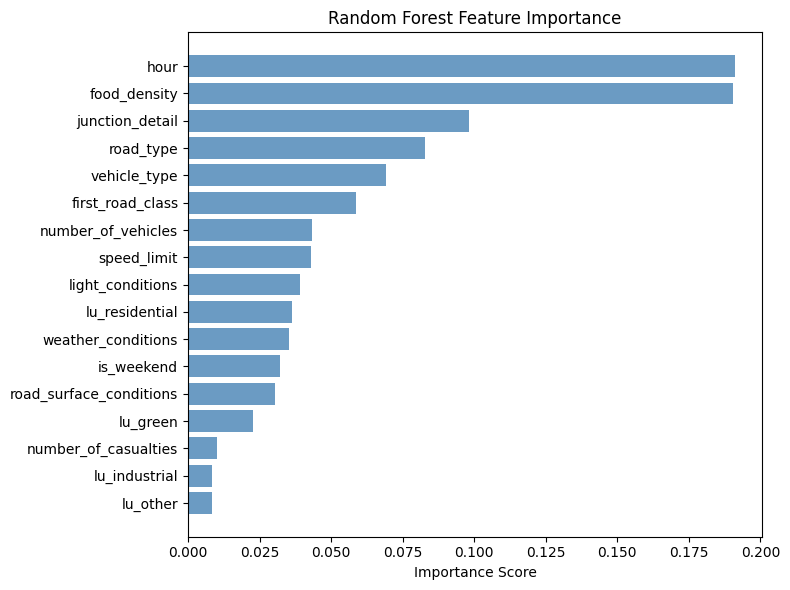

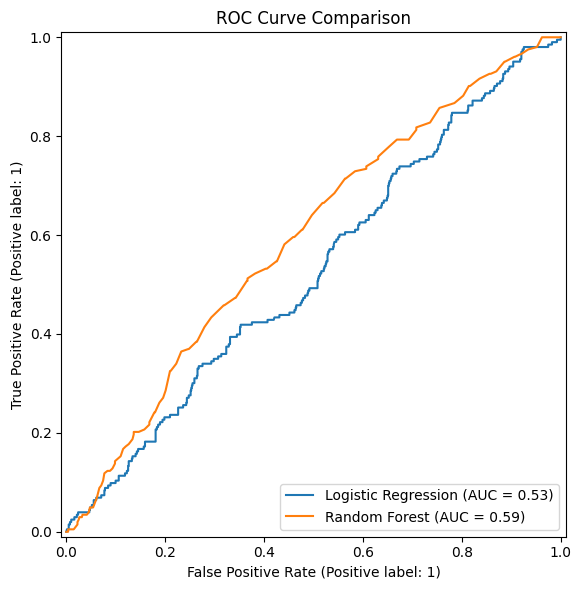

In [87]:
#  4.3 Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Slight','Serious/Fatal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

#   4.3.1Feature importance plot
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#   4.3.2 ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=ax)
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



Fourth, we calculated the SHAP value to interpret the random forest model, revealing which features are most important and the direction and strength of their influence on the prediction of severe or fatal consequences. To improve computational efficiency, we used a random sample containing 300 test observations, with a fixed random seed of 42 to ensure the reproducibility of the results.

All models were evaluated using ROC-AUC, precision, recall, and F1 score on a reserved test set containing 20% of the data.



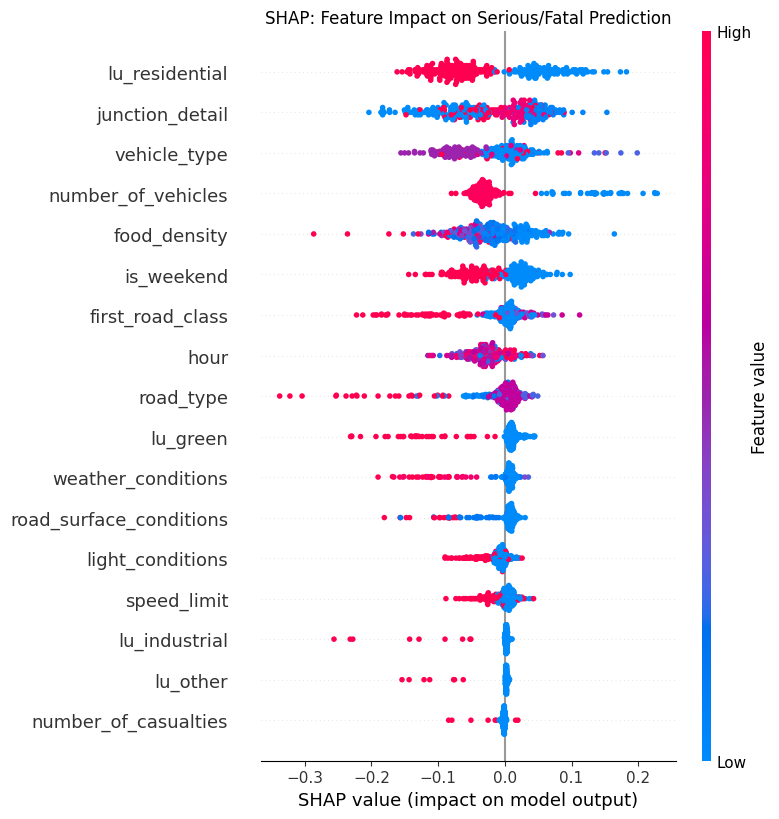

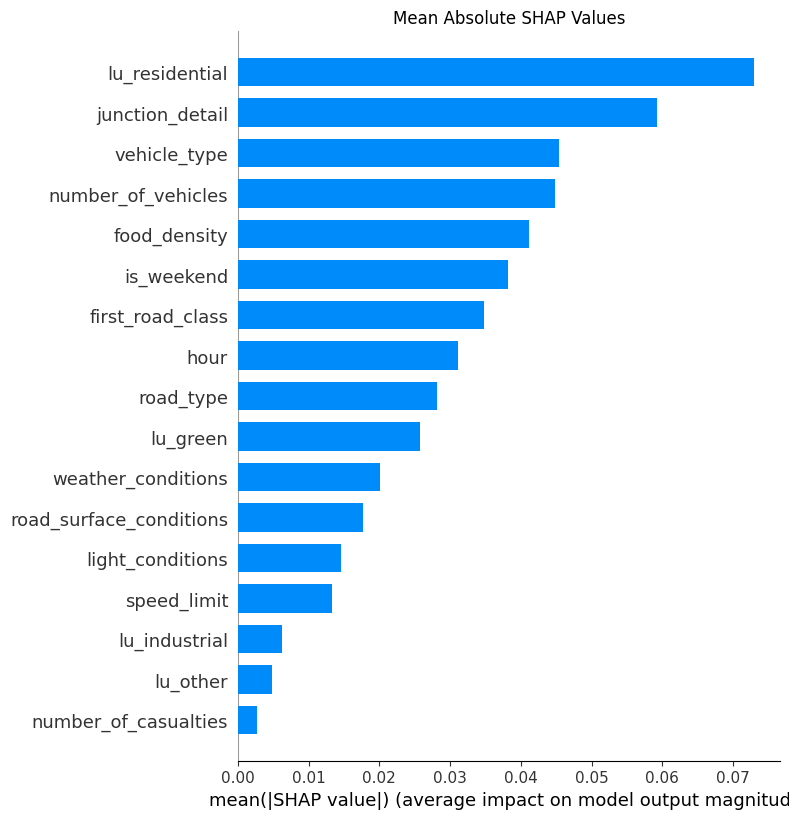

In [88]:
#  4.4 SHAP Analysis

explainer = shap.TreeExplainer(rf)
X_test_sample = X_test.sample(300, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Adapted to the output format of SHAP 0.51.0
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 = Serious/Fatal
else:
    shap_vals = shap_values[:, :, 1]

#  4.4.1 Beeswarm plot 
plt.figure()
shap.summary_plot(shap_vals, X_test_sample,
                  feature_names=features, show=False)
plt.title('SHAP: Feature Impact on Serious/Fatal Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

#  4.4.2 Bar plot 
plt.figure()
shap.summary_plot(shap_vals, X_test_sample,
                  feature_names=features, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Values')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()



## 5,0 Results and Discussion


### 5.1 Exploratory Data Analysis

EDA revealed two distinct temporal risk profiles: the highest serious rate 
occurs between 22:00 and 05:00, exceeding 30% at certain hours, while the greatest 
absolute volume of serious collisions falls in weekday evenings (17:00–22:00), 
coinciding with peak gig economy delivery activity (Christie & Ward, 2023). This 
distinction is important for intervention design — deep-night collisions are most 
likely fatal, but weekday evenings represent the greatest overall burden. Dual 
carriageways show the highest serious rate , and 70mph 
roads approach 38%, consistent with speed-severity literature (Antonella et al., 
2023). The correlation heatmap shows weak negative correlations for road surface 
conditions (r = −0.09) and weather conditions (r = −0.08), reflecting STATS19 
encoding convention: higher numeric codes represent more adverse conditions, so 
the negative direction indicates that dry conditions are associated with higher 
severity, likely because riders travel faster in good weather.

### 5.2 Logistic Regression

The logistic regression model achieved ROC-AUC of 0.527. number_of_casualties 
(β = +0.21) and light_conditions (β ≈ +0.05) show positive associations with 
serious outcomes. All land use dummies show negative coefficients relative to the 
commercial baseline — lu_other (β = −2.1) and lu_industrial (β = −1.5) are largest 
— suggesting commercial road environments carry comparatively higher severity risk. 
The negative is_weekend coefficient indicates weekday collisions are more severe, 
consistent with concentrated gig economy delivery activity on weekday evenings 
(Christie & Ward, 2023).

### 5.3 Random Forest and Feature Importance

The random forest achieved ROC-AUC of 0.593, outperforming logistic regression and 
better capturing non-linear relationships. The improvement over the baseline model 
(AUC = 0.562, without vehicle_type, first_road_class, and food_density) reflects 
the predictive value of these additional variables. lu_residential dominates feature 
importance, followed by junction_detail, vehicle_type, number_of_vehicles, and 
food_density. urban_or_rural_area was excluded due to extreme multicollinearity 
(VIF = 35.3) and negligible predictive contribution.

### 5.4 SHAP Analysis

SHAP analysis provides the most granular answer to RQ2. lu_residential records the 
highest mean absolute SHAP value, followed by junction_detail, vehicle_type, 
number_of_vehicles, and food_density. hour ranks eighth, indicating that once vehicle 
type, road hierarchy, and spatial exposure are accounted for, the marginal 
contribution of time of day is reduced.

High food_density values are associated with negative SHAP values, indicating lower 
predicted severity in commercially dense areas — typically zones with lower operating 
speeds and stricter traffic management. This supports a key distinction: high-density 
commercial areas generate more two-wheeler collisions due to greater delivery 
exposure, but incidents tend to be less severe. The weekday evening collision peak 
(17:00–22:00), combined with elevated motorcycle proportions in high food_density 
zones, indirectly supports the gig rider exposure hypothesis (Christie & Ward, 2023).

lu_residential collisions show negative SHAP values relative to commercial zones, 
yet lu_residential ranks as the most important predictor overall. This reflects the 
risk profile of arterial roads bordering residential areas, where higher speeds and 
less infrastructure protection elevate severity when collisions do occur. vehicle_type 
shows mixed SHAP distributions, confirming that motorcyclists face substantially 
different severity outcomes compared to cyclists (DfT, 2025).

Both models achieve modest ROC-AUC values (logistic regression: 0.527, random 
forest: 0.593), reflecting unobserved factors such as rider behaviour, helmet use, 
and vehicle condition absent from police-recorded data (Antonella et al., 2023). 
The highest-risk scenario involves motorcycle incidents at junctions in residential 
or mixed-use areas during weekday evenings — precisely the operational context of 
gig economy delivery riders (Christie & Ward, 2023).



## 6.0 Conclusion


This study used 4,966 collision records from the UK Department for Transport 2025 provisional dataset, combined with OSM land use data and catering establishment density information, to analyze temporal, road infrastructure, land use, and vehicle-level factors related to the severity of two-wheeler collisions in London.

For RQ1, the study found that intersection type, land use, vehicle type, and catering establishment density were key factors. Two distinct temporal risk characteristics were identified: collision severity was highest late at night (22:00–05:00), while the absolute value of severe injuries was highest on weekday evenings (17:00–22:00), coinciding with peak delivery times in the gig economy. For RQ2, SHAP analysis confirmed that lu_residential was the most influential single predictor, followed by junction_detail and vehicle_type. High food density was associated with lower accident severity, supporting the distinction between collision frequency and severity in densely populated commercial areas.

These findings suggest that redesigning intersections, implementing speed controls on residential arterial roads, and enacting safety programs for gig economy delivery platforms on weekday evenings hold the greatest potential for reducing serious and fatal collisions.

Both models exhibited low ROC-AUC values ​​(logistic regression: 0.527, random forest: 0.593), reflecting unobserved factors not included in police records, such as cyclist behavior and helmet usage. OSM spatial connectivity relies on a 50-meter buffer approximation, with food density serving only as a proxy for two-wheeled vehicle traffic rather than a direct measurement. Future research could incorporate real-time bicycle traffic data and bicycle infrastructure density as additional spatial predictors.



## 7.0 References


Christie, N. and Ward, H. (2023) 'Road collisions more likely for takeaway delivery riders working in the gig economy', *Safety Science*, 158, p. 105991. https://doi.org/10.1016/j.ssci.2022.105991

Department for Transport (DfT) (2025) *Reported Road Casualties Great Britain, Annual Report 2024*. London: Department for Transport. Available at: https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-annual-report-2024

European Commission (2025) *Road Safety Statistics 2025*. Brussels: European Commission Directorate-General for Transport. Available at: https://transport.ec.europa.eu/background/road-safety-statistics-2025_en

Mohamad, I., JomnonKwao, S. and Ratanavaraha, V. (2025) 'Machine learning predictive performance in road accident severity: A case study from Thailand', *Results in Engineering*, 26, p. 104833. https://doi.org/10.1016/j.rineng.2025.104833

Antonella, S., Maria, R. et al. (2023) 'Injury severity prediction of cyclist crashes using random forests and random parameters logit models', *Accident Analysis & Prevention*, 192, p. 107275. https://doi.org/10.1016/j.aap.2023.107275

Antonella, S., Matin, S. et al. (2025) 'Cyclist crash severity modeling: A hybrid approach of XGBoost-SHAP and random parameters logit with heterogeneity in means and variances', *Journal of Safety Research*, 93, pp. 373–398. https://doi.org/10.1016/j.jsr.2025.04.003

Sergio, A., Cristina, M. et al. (2026) 'Safety, identity, and inequity at the last mile: a qualitative study of app-based bicycle delivery riders in Spain', *Safety Science*, 199, p. 107180. https://doi.org/10.1016/j.ssci.2026.107180

Xiao, L., Si, Q. et al. (2025) 'E-scooter safety under scrutiny: Examining crash patterns and injuries in the UK', *Journal of Safety Research*, 92, pp. 292–305. https://doi.org/10.1016/j.jsr.2024.11.026

Jingjing, Z., Garyfallos, K. and Shahram, H. (2026) 'England-wide injury-severity analysis of e-scooter riders using a Bayesian spatial field model', *Accident Analysis & Prevention*, 232, p. 108517. https://doi.org/10.1016/j.aap.2026.108517